# Lab 03 Extra - Benchmark de Complexidade de Algoritmos
**Disciplina:** Estruturas de Dados | **Professor:** Luis Aramis

Neste laboratório extra, vamos explorar na prática o comportamento da **Complexidade de Algoritmos** e da **Notação Big O**.
Vamos comparar o tempo empírico de execução de diferentes algoritmos para atestar o fato de que a notação assintótica reflete muito bem as limitações reais das nossas máquinas.

## 1. Preparando os Dados
Vamos criar uma função para gerar listas de números aleatórios de diferentes tamanhos ($). Isso servirá como nosso "ambiente de testes".

In [1]:
import time
import random
import matplotlib.pyplot as plt

def gerar_dados(tamanho):
    """Gera uma lista de números inteiros aleatórios do tamanho especificado."""
    return [random.randint(1, 100000) for _ in range(tamanho)]

# Tamanhos de dataset que vamos testar
# Atenção: para algoritmos muito lentos como o Bubble Sort O(n^2), dobrar N multiplica por 4 o tempo!
# Valores muito grandes podem demorar os minutos da nossa aula. Vamos ser conservadores:
tamanhos_N = [100, 300, 600, 1000, 2000, 4000]

print(f"Tamanhos N que serão analisados: {tamanhos_N}")

Tamanhos N que serão analisados: [100, 300, 600, 1000, 2000, 4000]


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Implementando os Algoritmos

Agora vamos programar quatro funções com propósitos diferentes. Elas representam as classes de complexidade mais famosas do nosso curso.

### 2.1 Algoritmo (1)$ - Tempo Constante
O tempo de execução independe do tamanho dos dados de entrada ($). Por exemplo: Checar se o array está vazio e acessar o primeiro elemento.

In [3]:
def algoritmo_O1(dados):
    """Retorna o primeiro elemento se existir."""
    if len(dados) > 0:
        return dados[0]
    return None

### 2.2 Algoritmo (n)$ - Tempo Linear
O tempo de execução cresce na proporção do tamanho dos dados ($). Custo clássico do loop 
or. Exemplo: Iteração simples para descobrir o valor mínimo (Max/Min de Python escondem o loop C por baixo dos panos, mas iteram igual).

In [4]:
def algoritmo_On(dados):
    """Busca iterativa do menor valor da lista."""
    if not dados: return None
    minimo = dados[0]
    for num in dados:
        if num < minimo:
            minimo = num
    return minimo

### 2.3 Algoritmo (n \log n)$ - Tempo Log-Linear
Algoritmos iterativos poderosos da família dividir-para-conquistar (como Merge Sort). O Python tem um nativo brilhante, o Timsort, acessado via sort() ou sorted().

In [5]:
def algoritmo_On_log_n(dados):
    """Ordena dados delegando para o poderoso motor de C e Timsort da linguagem"""
    return sorted(dados)

### 2.4 Algoritmo (n^2)$ - Tempo Quadrático
O tempo de execução cresce pelo quadrado da entrada. 10x mais dados viram 100x mais lentidão. Muito comum ao fazer "um loop dentro do outro" para consultar pares. Ex: Implementação simples do Bubble Sort.

In [6]:
def algoritmo_On2(dados):
    """Bubble sort ineficiente - Compara cada elemento com todos os subsequentes"""
    arr = dados.copy()
    n = len(arr)
    for i in range(n):
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
    return arr

## 3. O Grande Teste (Benchmarking)

Chegou a hora. Vamos iterar sobre nossa lista de $, gerar dados aleatórios cada vez maiores e rodar os quatro algoritmos capturando o tempo no cronômetro da função 	ime.time().

In [7]:
tempos_O1 = []
tempos_On = []
tempos_On_log_n = []
tempos_On2 = []

print("Iniciando Benchmarking... Por favor aguarde o processamento.")

for n in tamanhos_N:
    print(f"\nTestando com N = {n}")
    # Gera dados de carga nova
    dados_teste = gerar_dados(n)
    
    # Teste O(1)
    inicio = time.time()
    algoritmo_O1(dados_teste)
    tempos_O1.append(time.time() - inicio)
    
    # Teste O(n)
    inicio = time.time()
    algoritmo_On(dados_teste)
    tempos_On.append(time.time() - inicio)
    
    # Teste O(n log n)
    inicio = time.time()
    algoritmo_On_log_n(dados_teste)
    tempos_On_log_n.append(time.time() - inicio)
    
    # Teste O(n^2)
    inicio = time.time()
    algoritmo_On2(dados_teste)
    tempos_On2.append(time.time() - inicio)

print("\nTerminou com sucesso!")

Iniciando Benchmarking... Por favor aguarde o processamento.

Testando com N = 100

Testando com N = 300

Testando com N = 600

Testando com N = 1000

Testando com N = 2000

Testando com N = 4000

Terminou com sucesso!


## 4. Visualizando as Curvas do Tempo

Nós, humanos, entendemos o mundo linearmente. Quando lidamos com exponenciação a surpresa é grande. É aqui que os gráficos salvam.

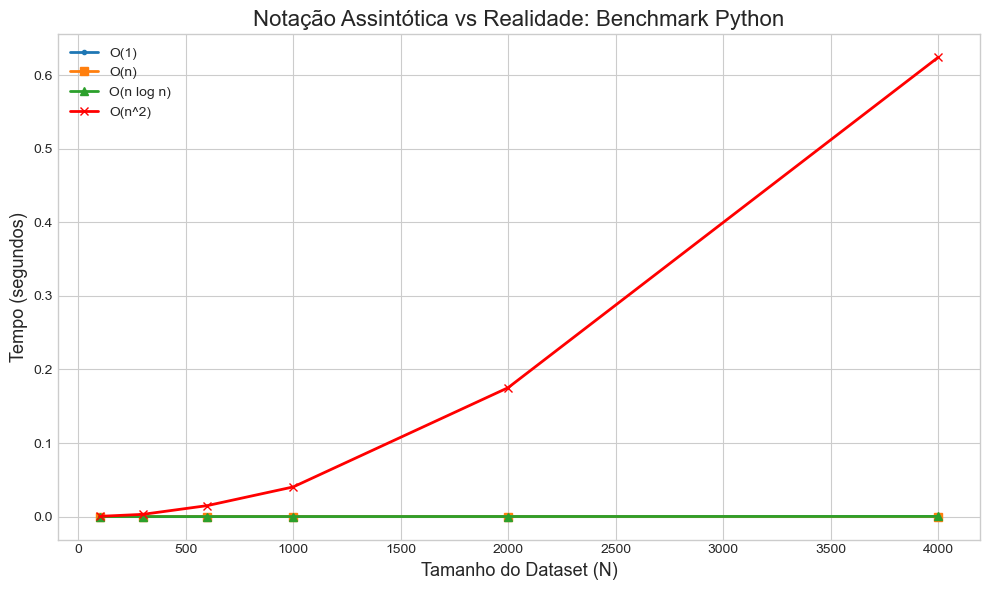

In [8]:
# Estilo mais limpo para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# Desenhando
plt.plot(tamanhos_N, tempos_O1, label='O(1)', marker='.', linewidth=2)
plt.plot(tamanhos_N, tempos_On, label='O(n)', marker='s', linewidth=2)
plt.plot(tamanhos_N, tempos_On_log_n, label='O(n log n)', marker='^', linewidth=2)
plt.plot(tamanhos_N, tempos_On2, label='O(n^2)', marker='x', color='red', linewidth=2)

plt.title('Notação Assintótica vs Realidade: Benchmark Python', fontsize=16)
plt.xlabel('Tamanho do Dataset (N)', fontsize=13)
plt.ylabel('Tempo (segundos)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

## O Paradoxo do Gráfico Esmagado

Você reparou que as retas O(n) e O(n log n) parecem simplesmente estar "deitadas no eixo zero" igual ao constante O(1)?

Isso acontece por conta da magnitude brutal na escala do quadrático O(n^2). Se a barra vertical precisa ir até 1.5s pra acomodar o crescimento ruim vermelho, 0.0001 milissegundos acaba não aparecendo.

Vamos plotar as três eficientes isoladas sem o Bubble Sort:

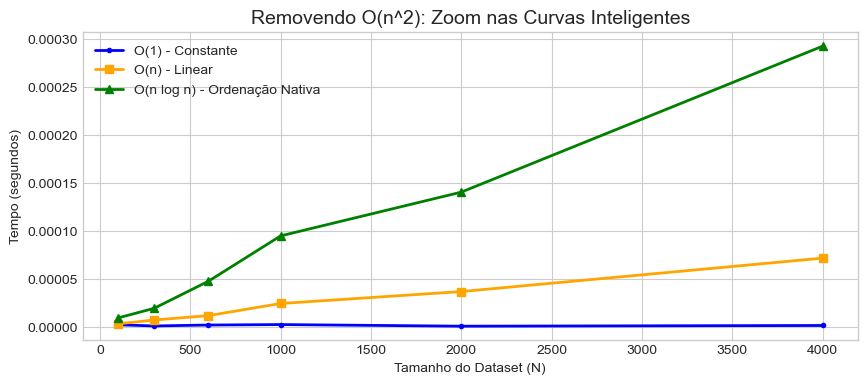

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(tamanhos_N, tempos_O1, label='O(1) - Constante', marker='.', color='blue', linewidth=2)
plt.plot(tamanhos_N, tempos_On, label='O(n) - Linear', marker='s', color='orange', linewidth=2)
plt.plot(tamanhos_N, tempos_On_log_n, label='O(n log n) - Ordenação Nativa', marker='^', color='green', linewidth=2)

plt.title('Removendo O(n^2): Zoom nas Curvas Inteligentes', fontsize=14)
plt.xlabel('Tamanho do Dataset (N)')
plt.ylabel('Tempo (segundos)')
plt.legend()
plt.show()

### Questão de Conclusão:
Escreva um pequeno texto com as suas conclusões sobre o experimento que acabamos de assistir aqui. Sabendo que é uma simulação modesta em N, imagine sistemas reais com  = Terabytes$.